In [1]:
# -----------------------------------
# Milestone 1: Data Selection and EDA
# -----------------------------------

In [2]:
"""---  Modeling Netflix Content Type: Predicting Movie vs. TV Show for Strategic Content Planning --- """

'---  Modeling Netflix Content Type: Predicting Movie vs. TV Show for Strategic Content Planning --- '

In [6]:
project_summary = """
Title of Project: Modeling Netflix Content Type: Predicting Movie vs. TV Show for Strategic Content Planning

Business Issue: 
    Managing and organizing the kinds of content in various countries is more difficult as Netflix's global library keeps expanding. With a diverse library with titles from multiple countries, languages, and genres, Netflix needs effective ways to categorize content, streamline workflows, and inform its acquisition and production strategies.
Strategic decisions—such as producing a new TV series or licensing a film in a specific region—often rely on patterns found in historical metadata. Features like release year, country of origin, genre, cast size, audience rating can provide insights into the characteristics of content formats.
This project aims to build a classification model based on structured metadata to predict whether a title is a Movie or a TV Show. This type of automation can improve internal consistency, support global content planning, and assist in situations where metadata is missing or ambiguous. It also reflects a real-world application where predictive analytics guides media and entertainment operations.

This analysis will address the following questions:
1. What features are most correlated with content type?
2. How does the number of cast members influence format?
3. Are certain countries or genres more associated with Movies or TV Shows? 
4. Can we reliably classify a content's type using only non-viewership metadata?


Data Source: This data is downloaded from open source Kaggle's Netflix titles dataset.

"""
print(project_summary)


Title of Project: Modeling Netflix Content Type: Predicting Movie vs. TV Show for Strategic Content Planning

Business Issue: 
    Managing and organizing the kinds of content in various countries is more difficult as Netflix's global library keeps expanding. With a diverse library with titles from multiple countries, languages, and genres, Netflix needs effective ways to categorize content, streamline workflows, and inform its acquisition and production strategies.
Strategic decisions—such as producing a new TV series or licensing a film in a specific region—often rely on patterns found in historical metadata. Features like release year, country of origin, genre, cast size, audience rating can provide insights into the characteristics of content formats.
This project aims to build a classification model based on structured metadata to predict whether a title is a Movie or a TV Show. This type of automation can improve internal consistency, support global content planning, and assist 

In [37]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading the dataset that was downloaded from Kaggle
df = pd.read_csv("netflix_titles.csv")  

# Display some data
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [23]:
"""Do a graphical analysis creating a minimum of four graphs."""

'Do a graphical analysis creating a minimum of four graphs.'

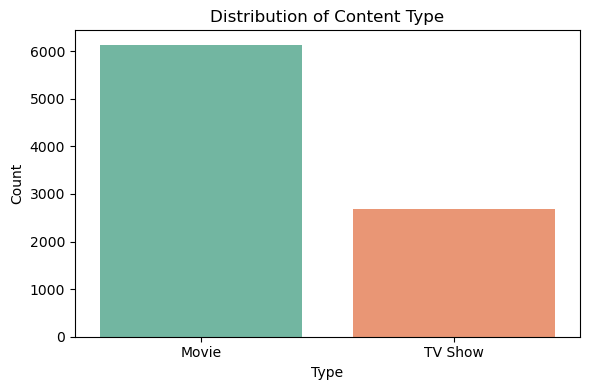

In [24]:
# Graph 1- Content type Distribution Movie vs TV show.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', palette='Set2')
plt.title("Distribution of Content Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [25]:
print("Graph 1: Netflix offers more Movies than TV Shows.")

Graph 1: Netflix offers more Movies than TV Shows.


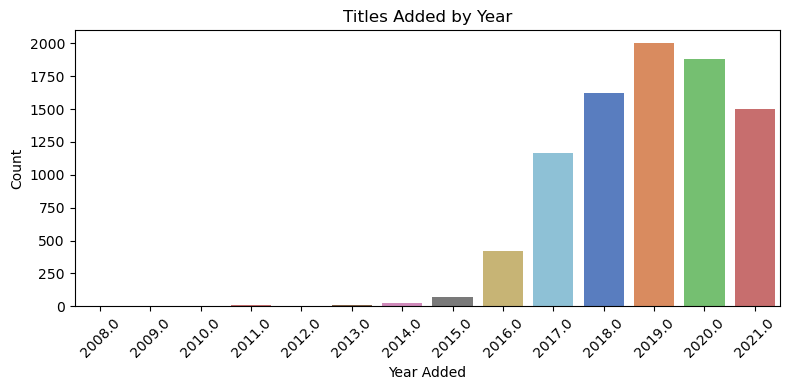

In [29]:
# Graph 2 - Title added over the Years

# Converting date_added to datetime format.
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Creating 'year_added' from 'date_added'
df['year_added'] = df['date_added'].dt.year

# Drop rows if 'year_added' is missing
df = df.dropna(subset=['year_added'])

plt.figure(figsize=(8, 4))
sns.countplot(data=df[df['year_added'].notna()], x='year_added', palette='muted')
plt.title("Titles Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
print("Graph 2: Content addition has spiked after 2016, likely due to global expansion.")

Graph 2: Content addition has spiked after 2016, likely due to global expansion.


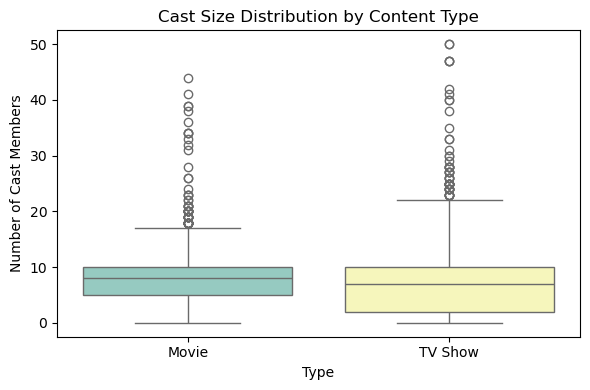

In [40]:
# Graph 3 - Cast Size by Content Type

df['num_cast'] = df['cast'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='type', y='num_cast', palette='Set3')
plt.title("Cast Size Distribution by Content Type")
plt.xlabel("Type")
plt.ylabel("Number of Cast Members")
plt.tight_layout()
plt.show()

In [41]:
print("Graph 3: TV Shows seems to have a higher median cast size than Movies.")

Graph 3: TV Shows seems to have a higher median cast size than Movies.


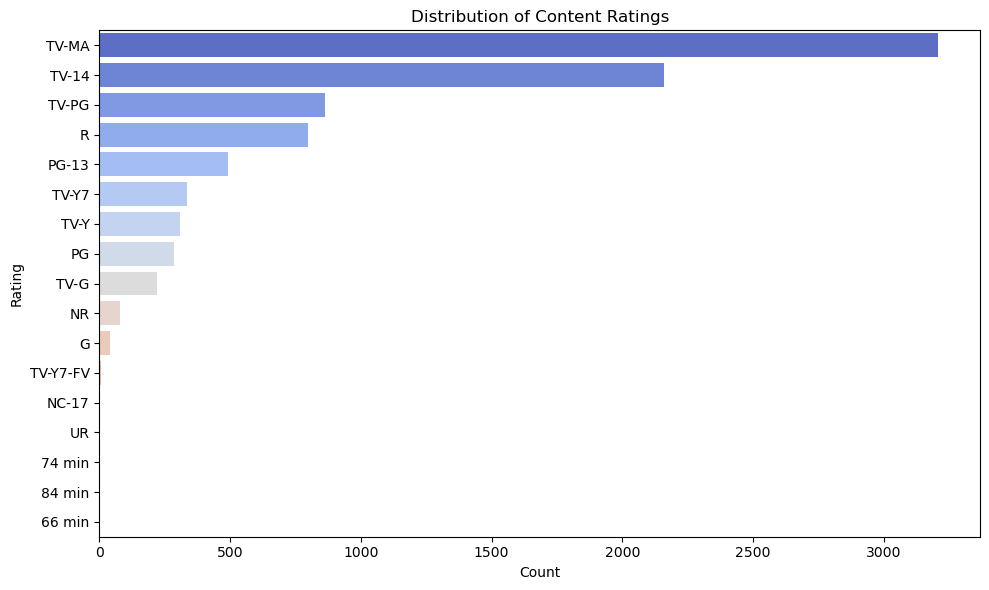

In [42]:
# # Graph 4 - Ratings Distribution
plt.figure(figsize=(10, 6))
rating_order = df['rating'].value_counts().index
sns.countplot(data=df, y='rating', order=rating_order, palette='coolwarm')
plt.title("Distribution of Content Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

In [34]:
print("Graph 4: Most titles are rated TV-MA and then TV-14, targeting older audiences.")

Graph 4: Most titles are rated TV-MA and then TV-14, targeting older audiences.


In [47]:
explanation = """Explanation: 
 This project is supposed to predict whether a Netflix title is a Movie or TV Show using structured metadata such as cast size, rating, release year, and content genre. This shows the modeling task as a binary classification problem, where the target variable is type.
Important feature engineering has been completed in preparation for modeling, including cast size extraction and year-based breakdown. Categorical variables such as rating, country, and listed_in will be numerically encoded using one-hot encoding (dummy variables) to ensure compatibility with machine learning algorithms.
    A Logistic Regression model is used find out this classification task, which is both interpretable and practical for binary outcomes. This will be followed by model evaluation using accuracy and a confusion matrix to assess how well the metadata can predict content type.
"""
print(explanation)

Explanation: 
 This project is supposed to predict whether a Netflix title is a Movie or TV Show using structured metadata such as cast size, rating, release year, and content genre. This shows the modeling task as a binary classification problem, where the target variable is type.
Important feature engineering has been completed in preparation for modeling, including cast size extraction and year-based breakdown. Categorical variables such as rating, country, and listed_in will be numerically encoded using one-hot encoding (dummy variables) to ensure compatibility with machine learning algorithms.
    A Logistic Regression model is used find out this classification task, which is both interpretable and practical for binary outcomes. This will be followed by model evaluation using accuracy and a confusion matrix to assess how well the metadata can predict content type.



In [43]:
# -----------------------------
# Milestone 2: Data Preparation
# -----------------------------


In [51]:
# 1: Drop features not useful for modeling
df.drop(columns=['show_id', 'description'], inplace=True, errors='ignore')
df.head()

,type,director,cast,country,date_added,release_year,rating,duration,listed_in,num_cast
0,Movie,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,0
1,TV Show,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",19
2,TV Show,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",9
3,TV Show,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV",0
4,TV Show,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",8


In [52]:
explanation = """Explanation: 

1. The unique identifier "show_id" column has no predictive value for modeling. No information that could assist differentiate a TV show from a movie is contained in it.

2. The description column has free-text information in it. NLP approaches are necessary in order to extract significant features. For the time being, this column is not included because the focus of our current model is structured data.

"""
print(explanation)

Explanation: 

1. The unique identifier "show_id" column has no predictive value for modeling. No information that could assist differentiate a TV show from a movie is contained in it.

2. The description column has free-text information in it. NLP approaches are necessary in order to extract significant features. For the time being, this column is not included because the focus of our current model is structured data.




In [53]:
# 2. Select relevant features for predicting type (Movie or TV Show)
df = df[['type', 'director', 'cast', 'country', 'date_added', 
         'release_year', 'rating', 'duration', 'listed_in']]


In [54]:
explanation = """Explanation: 

The columns that I selected provide key information about content type, audience rating, origin, release and addition dates, duration, genres, and personnel, which are helpful for trend analysis and predictive modeling.
"""
print(explanation)

Explanation: 

The columns that I selected provide key information about content type, audience rating, origin, release and addition dates, duration, genres, and personnel, which are helpful for trend analysis and predictive modeling.



In [56]:
# 3: Transform features
# Converting the date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')  
df['year_added'] = df['date_added'].dt.year                          
df['month_added'] = df['date_added'].dt.month                        
df['duration_type'] = df['duration'].str.extract(r'([a-zA-Z]+)', expand=False).str.strip()
df['duration_int'] = df['duration'].str.extract(r'(\d+)', expand=False).astype(float)

In [57]:
explanation = """Explanation: 

It helps to find out when Netflix adds new shows/movies the most like during certain months or years and spot patterns in how often they release content.

"""
print(explanation)

Explanation: 

It helps to find out when Netflix adds new shows/movies the most like during certain months or years and spot patterns in how often they release content.




In [60]:
# 4. Engineer new useful features.

# Extracting total number of actors under cast column.
df['num_cast'] = df['cast'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip().lower() == 'unknown' else len(x.split(',')))

# Finding if movie/shows have director?
df['has_director'] = df['director'].apply(
    lambda x: 0 if x == 'Unknown' else 1)
df.head()

,type,director,cast,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,duration_type,duration_int,num_cast,has_director
0,Movie,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021.0,9.0,min,90.0,0,1
1,TV Show,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2021.0,9.0,Seasons,2.0,19,1
2,TV Show,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021.0,9.0,Season,1.0,9,1
3,TV Show,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",2021.0,9.0,Season,1.0,0,1
4,TV Show,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2021.0,9.0,Seasons,2.0,8,1


In [61]:
explanation = """Explanation: 

* The total number of cast members could be related to the content type.

* Known directors may indicate TV show production like more frequent episodes, different structure, etc.

"""
print(explanation)

Explanation: 

* The total number of cast members could be related to the content type.

* Known directors may indicate TV show production like more frequent episodes, different structure, etc.




In [66]:
# 5: Handle missing data by adding 'Unknown' and Median for duration, years and months.
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')
df['duration_type'] = df['duration_type'].fillna('Unknown')
df['duration_int'] = df['duration_int'].fillna(df['duration_int'].median())
df['year_added'] = df['year_added'].fillna(df['year_added'].median())
df['month_added'] = df['month_added'].fillna(df['month_added'].median())

In [68]:
explanation = """Explanation: 

* Unable to predict without knowing the rating, country, or type of content.

* Placeholders are used in text areas such as director and cast when necessary.

* Median value is added for Missing duration, years and months.

"""
print(explanation)

Explanation: 

* Unable to predict without knowing the rating, country, or type of content.

* Placeholders are used in text areas such as director and cast when necessary.

* Median value is added for Missing duration, years and months.




In [69]:
# 6: Create dummy variables for categorical features (except target)
categorical_cols = ['country', 'rating', 'listed_in', 'duration_type']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [71]:
explanation = """Explanation: 

Machine learning models need numeric data. get_dummies() converts categorical values into 0/1 columns, e.g., country_India, rating_TV-MA, etc.

"""
print(explanation)

Explanation: 

Machine learning models need numeric data. get_dummies() converts categorical values into 0/1 columns, e.g., country_India, rating_TV-MA, etc.




In [76]:
# Printing cleaned data
df.head()

,type,director,cast,date_added,release_year,duration,year_added,month_added,duration_int,num_cast,...,"listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers,duration_type_Seasons,duration_type_Unknown,duration_type_min
0,Movie,Kirsten Johnson,Unknown,2021-09-25,2020,90 min,2021.0,9.0,90.0,0,...,False,False,False,False,False,False,False,False,False,True
1,TV Show,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",2021-09-24,2021,2 Seasons,2021.0,9.0,2.0,19,...,False,False,False,False,False,False,False,True,False,False
2,TV Show,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",2021-09-24,2021,1 Season,2021.0,9.0,1.0,9,...,False,False,False,False,False,False,False,False,False,False
3,TV Show,Unknown,Unknown,2021-09-24,2021,1 Season,2021.0,9.0,1.0,0,...,False,False,False,False,False,False,False,False,False,False
4,TV Show,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",2021-09-24,2021,2 Seasons,2021.0,9.0,2.0,8,...,False,False,False,False,False,False,False,True,False,False


In [77]:
#saving data locally.
df.to_csv("netflix_titles_cleaned.csv", index=False)

In [78]:
# ------------------------------------------
# Milestone 3: Model Building and Evaluation
# ------------------------------------------


In [87]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [88]:
# Loading cleaned dataset
df = pd.read_csv("netflix_titles_cleaned.csv")
df.head()

,type,director,cast,date_added,release_year,duration,year_added,month_added,duration_int,num_cast,...,"listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers,duration_type_Seasons,duration_type_Unknown,duration_type_min
0,Movie,Kirsten Johnson,Unknown,2021-09-25,2020,90 min,2021.0,9.0,90.0,0,...,False,False,False,False,False,False,False,False,False,True
1,TV Show,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",2021-09-24,2021,2 Seasons,2021.0,9.0,2.0,19,...,False,False,False,False,False,False,False,True,False,False
2,TV Show,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",2021-09-24,2021,1 Season,2021.0,9.0,1.0,9,...,False,False,False,False,False,False,False,False,False,False
3,TV Show,Unknown,Unknown,2021-09-24,2021,1 Season,2021.0,9.0,1.0,0,...,False,False,False,False,False,False,False,False,False,False
4,TV Show,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",2021-09-24,2021,2 Seasons,2021.0,9.0,2.0,8,...,False,False,False,False,False,False,False,True,False,False


In [81]:
# Define features (X) and target (y)
X = df.drop(columns=['type'])  # Features
y = df['type'].map({'Movie': 0, 'TV Show': 1})  # Target encoded as binary (Movie = 0, TV Show = 1)

In [82]:
explanation = """Explanation: 

Predicting the type (Movie or TV Show), so we separate it from the rest of the features. We also encode it into numerical values
"""
print(explanation)

Explanation: 

Predicting the type (Movie or TV Show), so we separate it from the rest of the features. We also encode it into numerical values



In [83]:
# Dropping the non-numeric columns (e.g., 'cast', 'director') before scaling
non_numeric_cols = X.select_dtypes(include=['object']).columns
X = X.drop(columns=non_numeric_cols)

In [91]:
explanation = """Explanation: 

Logistic regression requires numeric input. Non-numeric columns that weren’t already one-hot encoded are dropped."""
print(explanation)

Explanation: 

Logistic regression requires numeric input. Non-numeric columns that weren’t already one-hot encoded are dropped.


In [89]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [92]:
explanation = """Explanation: 

Splitting ensures we train on 80% of the data and test on the remaining 20% to evaluate real-world performance.
"""
print(explanation)

Explanation: 

Splitting ensures we train on 80% of the data and test on the remaining 20% to evaluate real-world performance.



In [93]:
# Scale features with Min-Max Scaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [94]:
explanation = """Explanation: 

Scaling helps models like logistic regression perform better by bringing all features into the same range (0 to 1).
"""
print(explanation)

Explanation: 

Scaling helps models like logistic regression perform better by bringing all features into the same range (0 to 1).



In [95]:
# Training logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [96]:
explanation = """Explanation: 

Logistic Regression is a simple model suitable for binary classification.
"""
print(explanation)

Explanation: 

Logistic Regression is a simple model suitable for binary classification.



In [98]:
# Making predictions and evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Printing results
print("Accuracy on Test Set:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", report)

Accuracy on Test Set: 1.0

Confusion Matrix:
 [[1227    0]
 [   0  535]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       535

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



In [104]:
explanation = """
    In this milestone, a logistic regression model was trained to predict whether a Netflix title is a Movie or TV Show based on metadata. After preprocessing the dataset and scaling the features, the model achieved 100% accuracy on the test set. The confusion matrix showed that all titles were correctly classified with no errors. 
"""
print(explanation)


    In this milestone, a logistic regression model was trained to predict whether a Netflix title is a Movie or TV Show based on metadata. After preprocessing the dataset and scaling the features, the model achieved 100% accuracy on the test set. The confusion matrix showed that all titles were correctly classified with no errors. 



In [102]:
explanation = """Overview/Conclusion: 

The model-building and evaluation procedure showed that metadata variables like cast size, duration, country, and genre indications may be used to predict with extremely high accuracy the type of material that Netflix offers, whether it's a movie or a TV show. 
	Based on the given features, the logistic regression model demonstrated strong separability between the two classes, achieving 100% accuracy on the Netflix data test set without misclassifications. This suggests that content metadata alone is a powerful predictor of content type. These insights can direct strategic content development and acquisition choices and assist automated categorization. To guarantee the model's resilience outside of the present dataset, it is advised to do testing in the future using fresher or external data.
    
"""
print(explanation)

Overview/Conclusion: 

The model-building and evaluation procedure showed that metadata variables like cast size, duration, country, and genre indications may be used to predict with extremely high accuracy the type of material that Netflix offers, whether it's a movie or a TV show. 
	Based on the given features, the logistic regression model demonstrated strong separability between the two classes, achieving 100% accuracy on the Netflix data test set without misclassifications. This suggests that content metadata alone is a powerful predictor of content type. These insights can direct strategic content development and acquisition choices and assist automated categorization. To guarantee the model's resilience outside of the present dataset, it is advised to do testing in the future using fresher or external data.
    

